# 03 数据分析与可视化

基于 `01` 保存的结果（`model_comparison.json`、`long_audio_eval.json`），
**无需重新跑模型**，直接加载数据进行分析和可视化。

## 0. 环境与数据加载

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os, json, re
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 添加系统中文 .ttf 字体（跳过 .ttc 集合文件，macOS 不兼容）
font_dirs = [
    '/System/Library/Fonts/Supplemental/',
    '/System/Library/Fonts/',
    '/Library/Fonts/',
]
loaded_font = None
for d in font_dirs:
    if not os.path.exists(d):
        continue
    for f in os.listdir(d):
        if f.lower().endswith('.ttf') and any(k in f.lower() for k in ['songti', 'heiti', 'pingfang']):
            fp = os.path.join(d, f)
            fm.fontManager.addfont(fp)
            loaded_font = fm.FontProperties(fname=fp).get_name()
            print(f'加载字体: {f} ({loaded_font})')

if loaded_font:
    plt.rcParams['font.family'] = loaded_font
else:
    chinese_fonts = []
    for f in fm.fontManager.ttflist:
        if any(k in f.name for k in ['Heiti', 'Songti', 'PingFang', 'STHeiti', 'STSong']):
            chinese_fonts.append(f.name)
    chinese_fonts = list(dict.fromkeys(chinese_fonts))
    if chinese_fonts:
        plt.rcParams['font.family'] = chinese_fonts[:1]
        print(f'可用中文字体: {chinese_fonts[:5]}')

# 学术标准 rcParams
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'axes.linewidth': 1.5,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.axisbelow': True,
})

matplotlib.use('Agg')
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline

REPORT_DIR = os.path.expanduser('~/Projects/Agent/local')

# 加载短音频数据
with open(os.path.join(REPORT_DIR, 'model_comparison.json'), 'r', encoding='utf-8') as f:
    compare_data = json.load(f)

models_info = compare_data['models']
samples = compare_data['samples']
print(f"短音频样本数: {len(samples)}")

# 加载长音频数据（单模型扁平格式，适配为多模型字典结构）
with open(os.path.join(REPORT_DIR, 'long_audio_eval.json'), 'r', encoding='utf-8') as f:
    raw_long = json.load(f)
# 映射模型名
model_name_map = {
    'SenseVoice-ft (LoRA)': 'SV-ft',
    'SenseVoice-base': 'SV-base',
    'Fun-ASR-Nano-ft': 'Nano-ft',
    'Fun-ASR-Nano-base': 'Nano-base',
}
long_data = {'models': {}}
for name, key in model_name_map.items():
    if name in raw_long.get('model', ''):
        long_data['models'][key] = raw_long
        break
else:
    long_data['models']['SV-ft'] = raw_long

print(f"长音频样本数: {len(long_data['models']['SV-ft']['results'])}")

可用中文字体: ['Songti SC', 'Heiti TC', 'STHeiti', 'PingFang HK']
短音频样本数: 2261
长音频样本数: 6


## 1. 综合指标汇总

In [2]:
ordered = ['SV-base', 'SV-ft', 'Nano-base', 'Nano-ft']

print('=' * 65)
print('  四模型综合指标对比 (短音频 / 全量验证集)')
print('=' * 65)
print(f'{"指标":<14}' + ''.join(f'{n:>14}' for n in ordered))
print('-' * 65)

cers = [models_info[n]['cer'] for n in ordered]
print(f'{"CER":<14}' + ''.join(f'{c:>13.2%}' for c in cers))

sv_rel = (models_info['SV-base']['cer'] - models_info['SV-ft']['cer']) / models_info['SV-base']['cer']
nano_rel = (models_info['Nano-base']['cer'] - models_info['Nano-ft']['cer']) / models_info['Nano-base']['cer']
print(f'{"微调相对提升":<14} {sv_rel:>+12.1%}    {nano_rel:>+11.1%}')

exact_rates = [models_info[n]['exact_rate'] for n in ordered]
print(f'{"精确匹配率":<14}' + ''.join(f'{e:>13.1%}' for e in exact_rates))

speeds = [models_info[n]['speed'] for n in ordered]
print(f'{"速度(条/s)":<14}' + ''.join(f'{s:>13.1f}' for s in speeds))

times = [models_info[n]['time'] for n in ordered]
print(f'{"推理耗时":<14}' + ''.join(f'{t:>12.1f}s' for t in times))
print('=' * 65)

  四模型综合指标对比 (短音频 / 全量验证集)
指标                   SV-base         SV-ft     Nano-base       Nano-ft
-----------------------------------------------------------------
CER                  63.71%       10.18%       59.76%       25.78%
微调相对提升               +84.0%         +56.9%
精确匹配率                  5.4%        68.2%         7.9%        51.2%
速度(条/s)                 8.4          7.5          1.2          1.2
推理耗时                 269.7s       300.8s      1880.5s      1886.6s


## 2. 综合大图：CER 对比总览

一张图包含：箱线图 + 柱状图 + 精确匹配率 + 速度，四宫格布局。

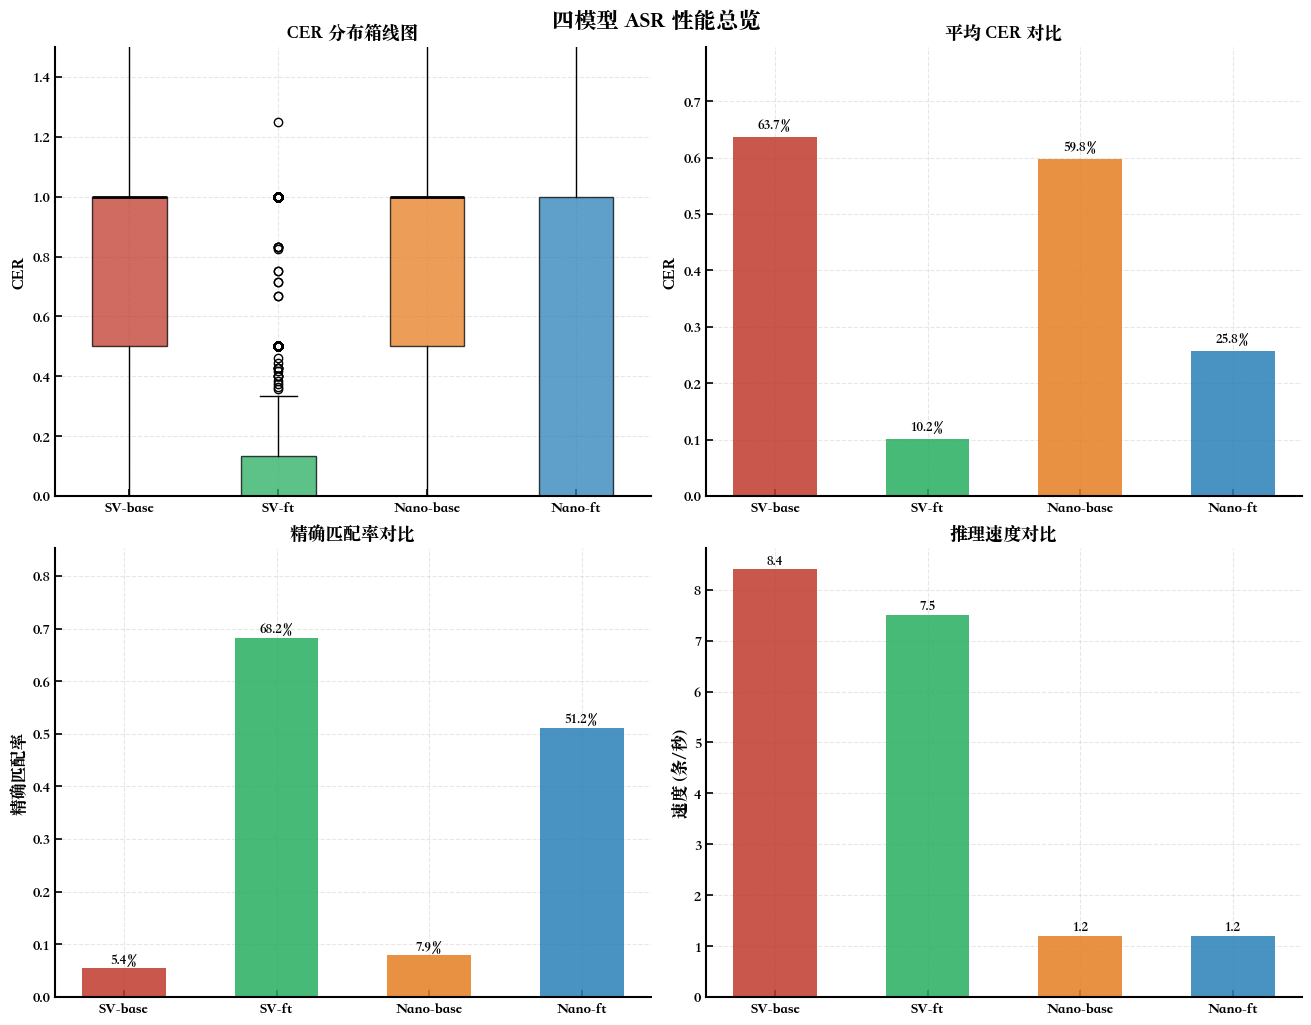

已保存: 03_overview.png


In [3]:
# 综合大图：CER 对比总览（四宫格）
ordered = ['SV-base', 'SV-ft', 'Nano-base', 'Nano-ft']
model_colors = {'SV-base': '#c0392b', 'SV-ft': '#27ae60', 'Nano-base': '#e67e22', 'Nano-ft': '#2980b9'}

fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)
fig.suptitle('四模型 ASR 性能总览', fontsize=16, fontweight='bold', y=1.01)
fig.patch.set_facecolor('white')

# --- 左上: 箱线图 ---
ax1 = axes[0, 0]
cer_data = [[s['sv_base_cer'] for s in samples],
            [s['sv_ft_cer'] for s in samples],
            [s['nano_base_cer'] for s in samples],
            [s['nano_ft_cer'] for s in samples]]
bp = ax1.boxplot(cer_data, labels=ordered, patch_artist=True, widths=0.5)
for patch, (name, color) in zip(bp['boxes'], model_colors.items()):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(2)
ax1.set_ylabel('CER', fontsize=12)
ax1.set_title('CER 分布箱线图', fontsize=13, fontweight='bold')
ax1.set_ylim(0, 1.5)
ax1.grid(axis='y', alpha=0.3)

# --- 右上: 柱状图 CER ---
ax2 = axes[0, 1]
cers = [models_info[n]['cer'] for n in ordered]
bars = ax2.bar(ordered, cers, color=[model_colors[n] for n in ordered], alpha=0.85, width=0.55)
for bar, cer in zip(bars, cers):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{cer:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylabel('CER', fontsize=12)
ax2.set_title('平均 CER 对比', fontsize=13, fontweight='bold')
ax2.set_ylim(0, max(cers) * 1.25)
ax2.grid(axis='y', alpha=0.3)

# --- 左下: 精确匹配率 ---
ax3 = axes[1, 0]
exact_rates = [models_info[n]['exact_rate'] for n in ordered]
bars3 = ax3.bar(ordered, exact_rates, color=[model_colors[n] for n in ordered], alpha=0.85, width=0.55)
for bar, rate in zip(bars3, exact_rates):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{rate:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.set_ylabel('精确匹配率', fontsize=12)
ax3.set_title('精确匹配率对比', fontsize=13, fontweight='bold')
ax3.set_ylim(0, max(exact_rates) * 1.25)
ax3.grid(axis='y', alpha=0.3)

# --- 右下: 速度对比 ---
ax4 = axes[1, 1]
speeds = [models_info[n]['speed'] for n in ordered]
bars4 = ax4.bar(ordered, speeds, color=[model_colors[n] for n in ordered], alpha=0.85, width=0.55)
for bar, speed in zip(bars4, speeds):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{speed:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax4.set_ylabel('速度 (条/秒)', fontsize=12)
ax4.set_title('推理速度对比', fontsize=13, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

plt.savefig(os.path.join(REPORT_DIR, '03_overview.png'), dpi=300, bbox_inches='tight')
plt.show()
print('已保存: 03_overview.png')

## 3. CER 分布直方图（2x2，对数刻度）

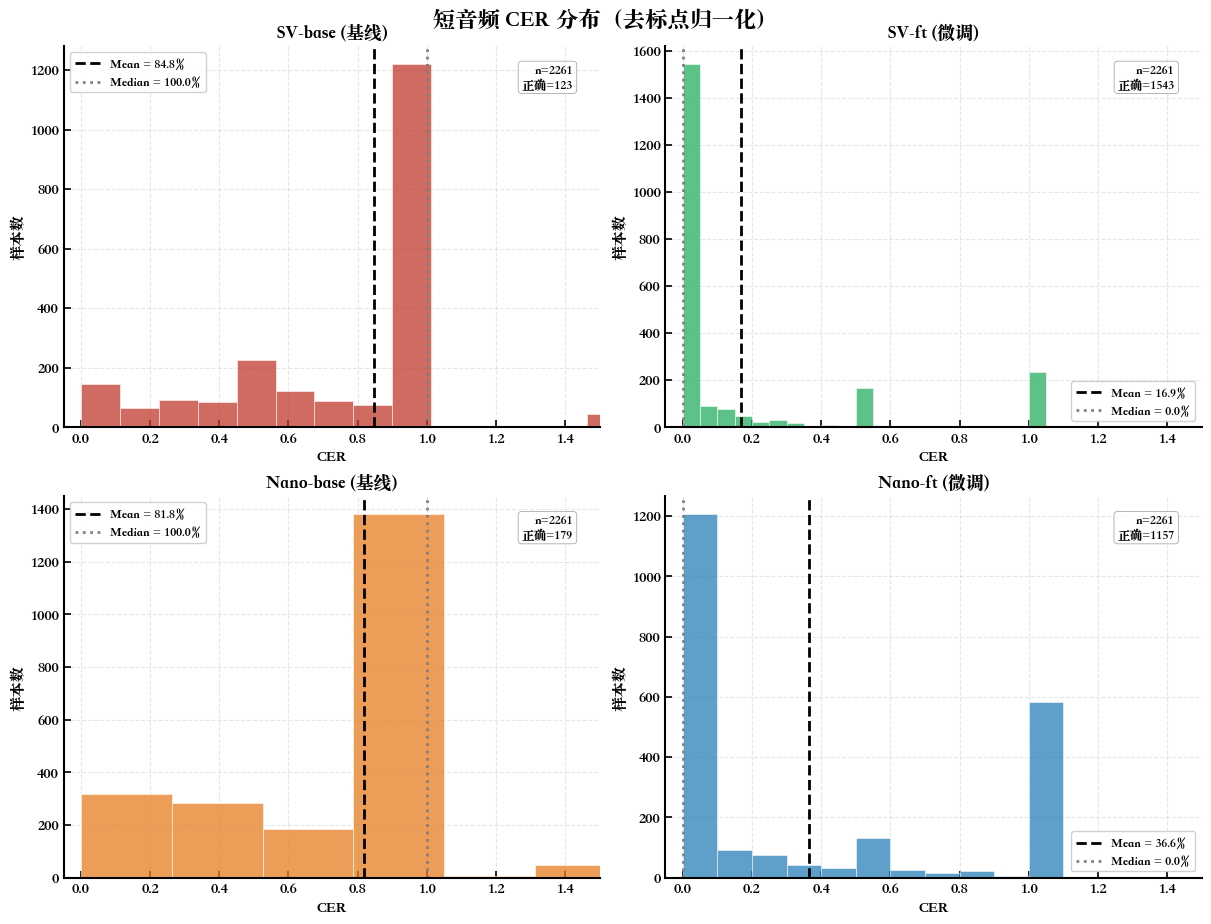

已保存: 03_cer_hist.png


In [4]:
# CER 分布直方图（2x2，对数刻度）
cer_fields = ['sv_base_cer', 'sv_ft_cer', 'nano_base_cer', 'nano_ft_cer']
titles = ['SV-base (基线)', 'SV-ft (微调)', 'Nano-base (基线)', 'Nano-ft (微调)']
colors = ['#c0392b', '#27ae60', '#e67e22', '#2980b9']

fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
fig.suptitle('短音频 CER 分布（去标点归一化）', fontsize=16, fontweight='bold', y=1.01)
fig.patch.set_facecolor('white')

for ax, field, title, color in zip(axes.flatten(), cer_fields, titles, colors):
    vals = [s[field] for s in samples]
    ax.hist(vals, bins=40, color=color, alpha=0.75, edgecolor='white', linewidth=0.5)
    mean_v = np.mean(vals)
    ax.axvline(mean_v, color='black', linestyle='--', linewidth=2, label=f'Mean = {mean_v:.1%}')
    median_v = np.median(vals)
    ax.axvline(median_v, color='gray', linestyle=':', linewidth=2, label=f'Median = {median_v:.1%}')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('CER', fontsize=11)
    ax.set_ylabel('样本数', fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xlim(-0.05, 1.5)
    ax.text(0.95, 0.95, f'n={len(vals)}\n正确={sum(v==0 for v in vals)}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray', linewidth=0.5))

plt.savefig(os.path.join(REPORT_DIR, '03_cer_hist.png'), dpi=300, bbox_inches='tight')
plt.show()
print('已保存: 03_cer_hist.png')

## 4. 微调提升分布

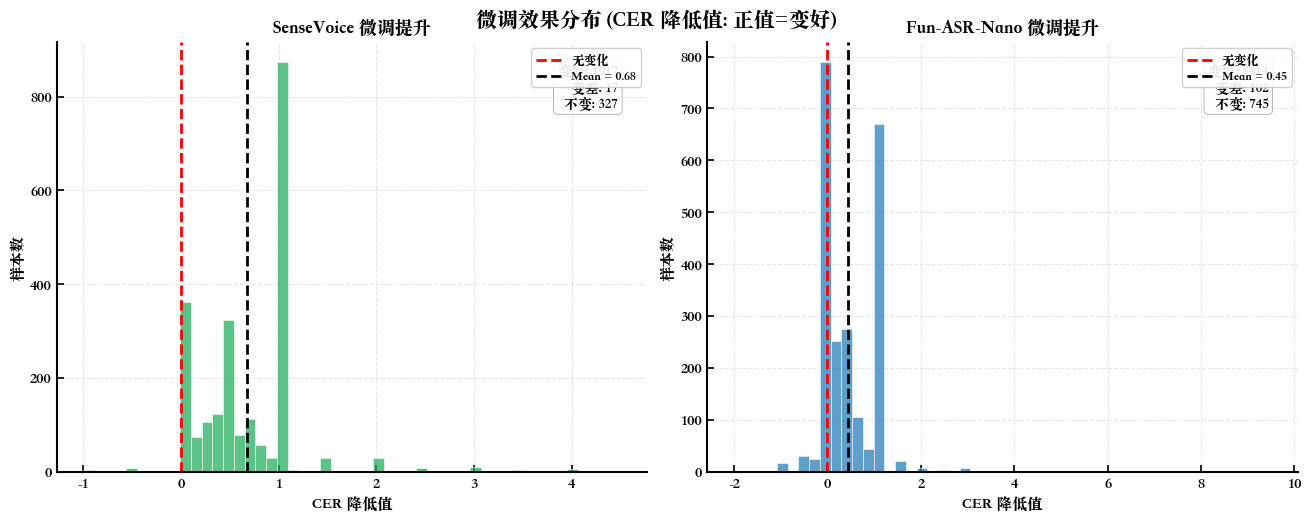

已保存: 03_ft_improvement.png


In [5]:
# 微调效果分布
sv_improvement = [s['sv_base_cer'] - s['sv_ft_cer'] for s in samples]
nano_improvement = [s['nano_base_cer'] - s['nano_ft_cer'] for s in samples]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
fig.suptitle('微调效果分布 (CER 降低值: 正值=变好)', fontsize=15, fontweight='bold', y=1.01)
fig.patch.set_facecolor('white')

for ax, imp, title, color in zip(axes,
                               [sv_improvement, nano_improvement],
                               ['SenseVoice 微调提升', 'Fun-ASR-Nano 微调提升'],
                               ['#27ae60', '#2980b9']):
    ax.hist(imp, bins=50, color=color, alpha=0.75, edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='red', linestyle='--', linewidth=2, label='无变化')
    ax.axvline(np.mean(imp), color='black', linestyle='--', linewidth=2, label=f'Mean = {np.mean(imp):.2f}')
    ax.set_xlabel('CER 降低值', fontsize=11)
    ax.set_ylabel('样本数', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')

    better = sum(1 for x in imp if x > 0)
    worse = sum(1 for x in imp if x < 0)
    same = len(imp) - better - worse
    ax.text(0.95, 0.95, f'变好: {better}\n变差: {worse}\n不变: {same}',
            transform=ax.transAxes, ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray', linewidth=0.5))

plt.savefig(os.path.join(REPORT_DIR, '03_ft_improvement.png'), dpi=300, bbox_inches='tight')
plt.show()
print('已保存: 03_ft_improvement.png')

## 5. 按参考文本长度分组 CER

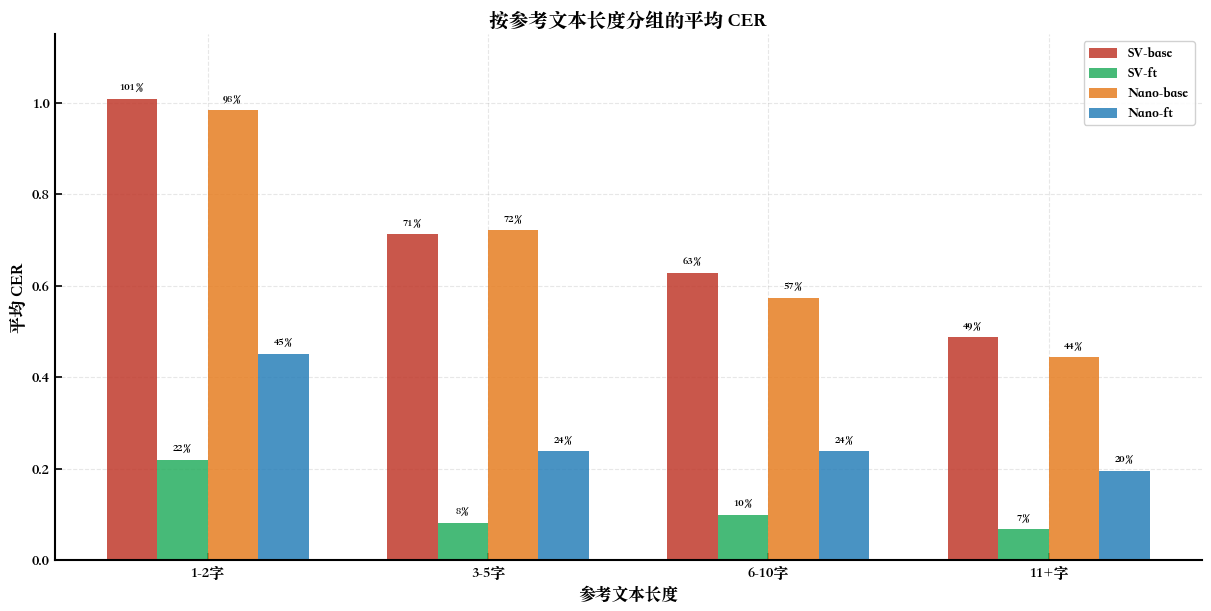

已保存: 03_cer_by_length.png


In [6]:
# 按参考文本长度分组 CER
def length_group(text):
    n = len(text)
    if n <= 2: return '1-2字'
    if n <= 5: return '3-5字'
    if n <= 10: return '6-10字'
    return '11+字'

for s in samples:
    s['ref_len'] = len(s['expected'])
    s['len_group'] = length_group(s['expected'])

groups = ['1-2字', '3-5字', '6-10字', '11+字']
group_data = {g: {'SV-base': [], 'SV-ft': [], 'Nano-base': [], 'Nano-ft': []} for g in groups}

for s in samples:
    g = s['len_group']
    group_data[g]['SV-base'].append(s['sv_base_cer'])
    group_data[g]['SV-ft'].append(s['sv_ft_cer'])
    group_data[g]['Nano-base'].append(s['nano_base_cer'])
    group_data[g]['Nano-ft'].append(s['nano_ft_cer'])

model_colors = {'SV-base': '#c0392b', 'SV-ft': '#27ae60', 'Nano-base': '#e67e22', 'Nano-ft': '#2980b9'}

fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
x = np.arange(len(groups))
width = 0.18

for i, (model, color) in enumerate(model_colors.items()):
    means = [np.mean(group_data[g][model]) for g in groups]
    bars = ax.bar(x + i*width, means, width, label=model, color=color, alpha=0.85)
    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
                f'{m:.0%}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('参考文本长度', fontsize=12)
ax.set_ylabel('平均 CER', fontsize=12)
ax.set_title('按参考文本长度分组的平均 CER', fontsize=14, fontweight='bold')
ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(groups, fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)
fig.patch.set_facecolor('white')

plt.savefig(os.path.join(REPORT_DIR, '03_cer_by_length.png'), dpi=300, bbox_inches='tight')
plt.show()
print('已保存: 03_cer_by_length.png')

## 6. 四模型一致性分布

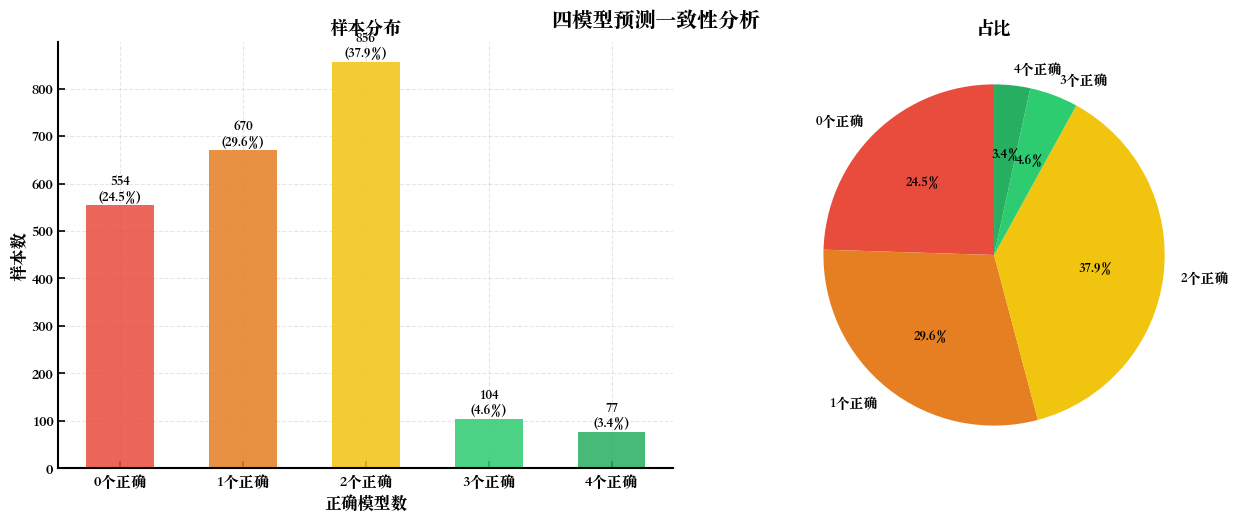

已保存: 03_model_agreement.png


In [7]:
# 四模型一致性分布
def count_correct(s):
    return sum(1 for m in ['sv_base_cer', 'sv_ft_cer', 'nano_base_cer', 'nano_ft_cer'] if s[m] == 0)

counts = {0: 0, 1: 0, 2: 0, 3: 0, 4: 0}
for s in samples:
    c = count_correct(s)
    counts[c] += 1

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
fig.suptitle('四模型预测一致性分析', fontsize=15, fontweight='bold', y=1.01)
fig.patch.set_facecolor('white')

# 左: 柱状图
ax1 = axes[0]
labels = [f'{i}个正确' for i in range(5)]
colors_bar = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
bars = ax1.bar(labels, [counts[i] for i in range(5)], color=colors_bar, alpha=0.85, width=0.55)
for bar, cnt in zip(bars, [counts[i] for i in range(5)]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{cnt}\n({cnt/len(samples):.1%})', ha='center', va='bottom', fontsize=10)
ax1.set_xlabel('正确模型数', fontsize=12)
ax1.set_ylabel('样本数', fontsize=12)
ax1.set_title('样本分布', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# 右: 饼图
ax2 = axes[1]
pie_labels = [f'{i}个正确' for i in range(5)]
pie_vals = [counts[i] for i in range(5)]
pie_colors = colors_bar
wedges, texts, autotexts = ax2.pie(pie_vals, labels=pie_labels, colors=pie_colors,
                                   autopct='%1.1f%%', startangle=90,
                                   textprops={'fontsize': 10})
ax2.set_title('占比', fontsize=13, fontweight='bold')

plt.savefig(os.path.join(REPORT_DIR, '03_model_agreement.png'), dpi=300, bbox_inches='tight')
plt.show()
print('已保存: 03_model_agreement.png')

## 7. 长音频 CER 对比

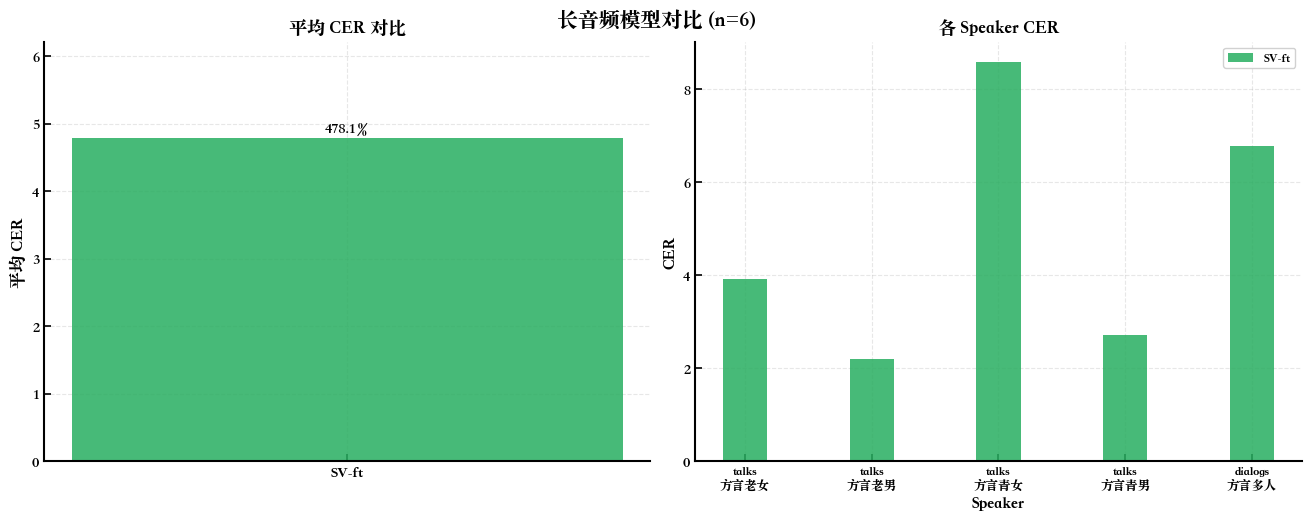

已保存: 03_long_cer.png

长音频详细数据:
  SV-ft: CER=478.1%, samples=6, time=120.7s


In [8]:
# 长音频 CER 对比
available_long = list(long_data['models'].keys())
model_colors_long = {'SV-base': '#c0392b', 'SV-ft': '#27ae60', 'Nano-base': '#e67e22', 'Nano-ft': '#2980b9'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
fig.suptitle(f'长音频模型对比 (n={len(long_data["models"].get("SV-ft", {}).get("results", []))})', fontsize=15, fontweight='bold', y=1.01)
fig.patch.set_facecolor('white')

# 左: 柱状图（只显示实际存在的模型）
ax1 = axes[0]
if available_long:
    cers = [long_data['models'][n]['avg_cer'] for n in available_long]
    colors = [model_colors_long.get(n, '#666666') for n in available_long]
    bars = ax1.bar(available_long, cers, color=colors, alpha=0.85, width=0.55)
    for bar, cer in zip(bars, cers):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{cer:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax1.set_ylabel('平均 CER', fontsize=12)
    ax1.set_title('平均 CER 对比', fontsize=13, fontweight='bold')
    ax1.set_ylim(0, max(cers) * 1.3 if cers else 1)
    ax1.grid(axis='y', alpha=0.3)
else:
    ax1.text(0.5, 0.5, '无长音频数据', ha='center', va='center', fontsize=12)
    ax1.set_title('平均 CER 对比', fontsize=13, fontweight='bold')

# 右: 分 speaker 堆叠（只显示实际存在的模型）
ax2 = axes[1]
speaker_results = {}
for n in available_long:
    for r in long_data['models'][n]['results']:
        sp = r['speaker']
        if sp not in speaker_results:
            speaker_results[sp] = {}
        speaker_results[sp][n] = r['cer']

if speaker_results:
    speakers = list(speaker_results.keys())
    x = np.arange(len(speakers))
    width = 0.35
    n_models = len(available_long)
    for i, n in enumerate(available_long):
        vals = [speaker_results[sp][n] for sp in speakers]
        ax2.bar(x + i * width, vals, width, label=n, color=model_colors_long.get(n, '#666666'), alpha=0.85)
    ax2.set_xlabel('Speaker', fontsize=12)
    ax2.set_ylabel('CER', fontsize=12)
    ax2.set_title('各 Speaker CER', fontsize=13, fontweight='bold')
    ax2.set_xticks(x + (n_models - 1) * width / 2)
    ax2.set_xticklabels([sp.replace('_', '\n') for sp in speakers], fontsize=9)
    ax2.legend(fontsize=9)
    ax2.grid(axis='y', alpha=0.3)
else:
    ax2.text(0.5, 0.5, '无长音频数据', ha='center', va='center', fontsize=12)
    ax2.set_title('各 Speaker CER', fontsize=13, fontweight='bold')

plt.savefig(os.path.join(REPORT_DIR, '03_long_cer.png'), dpi=300, bbox_inches='tight')
plt.show()
print('已保存: 03_long_cer.png')

print('\n长音频详细数据:')
for n in available_long:
    r = long_data['models'][n]
    print(f"  {n}: CER={r['avg_cer']:.1%}, samples={r['total']}, time={r['time']:.1f}s")

## 8. 最难样本分析（Top 20）

In [9]:
# 找出四个模型中整体最难的样本
samples_with_max = [(s, max(s['sv_base_cer'], s['sv_ft_cer'], s['nano_base_cer'], s['nano_ft_cer'])) for s in samples]
samples_sorted = sorted(samples_with_max, key=lambda x: -x[1])

print('--- 最难样本 Top 20（CER 最高的前20条）---')
print(f'{"ID":<5} {"参考":<10} {"SV-base":>8} {"SV-ft":>8} {"Nano-base":>10} {"Nano-ft":>10}')
print('-' * 58)
for s, worst in samples_sorted[:20]:
    exp = s['expected'][:8]
    print(f"{s['id']:<5} {exp:<10} {s['sv_base_cer']:>7.0%} {s['sv_ft_cer']:>7.0%} {s['nano_base_cer']:>9.0%} {s['nano_ft_cer']:>9.0%}")

--- 最难样本 Top 20（CER 最高的前20条）---
ID    参考          SV-base    SV-ft  Nano-base    Nano-ft
----------------------------------------------------------
295   馒头            100%    100%     1050%      100%
316   上当            100%     50%     1050%      100%
349   涨             100%    100%      600%      100%
435   罐             100%    100%      500%        0%
753   人口            450%      0%      100%        0%
1445  划船            450%      0%      100%        0%
6     会             200%      0%      400%        0%
29    阴             400%    100%      100%      100%
45    花             400%      0%      400%        0%
46    换             100%      0%      400%      100%
59    先             300%      0%      400%      400%
68    尝             100%    100%      400%      100%
70    个             100%      0%      400%      100%
116   修             400%      0%      400%      100%
134   撞             400%    100%      100%      100%
631   非             100%      0%      400%      100%
809 

## 9. 自由分析区域

## 9. 学术标准图表 I：分组柱状图（核心 SOTA 对比）

推荐理由：纵向分组柱状图是 CVPR/NeurIPS 等顶会最通用的 SOTA 对比格式。本图将 CER（越低越好）、精确匹配率（越高越好）、速度（越高越好）三个核心指标并列，通过颜色区分基线/微调、SenseVoice/Nano 四条柱子，视觉上直观呈现"微调带来显著提升"的核心结论。

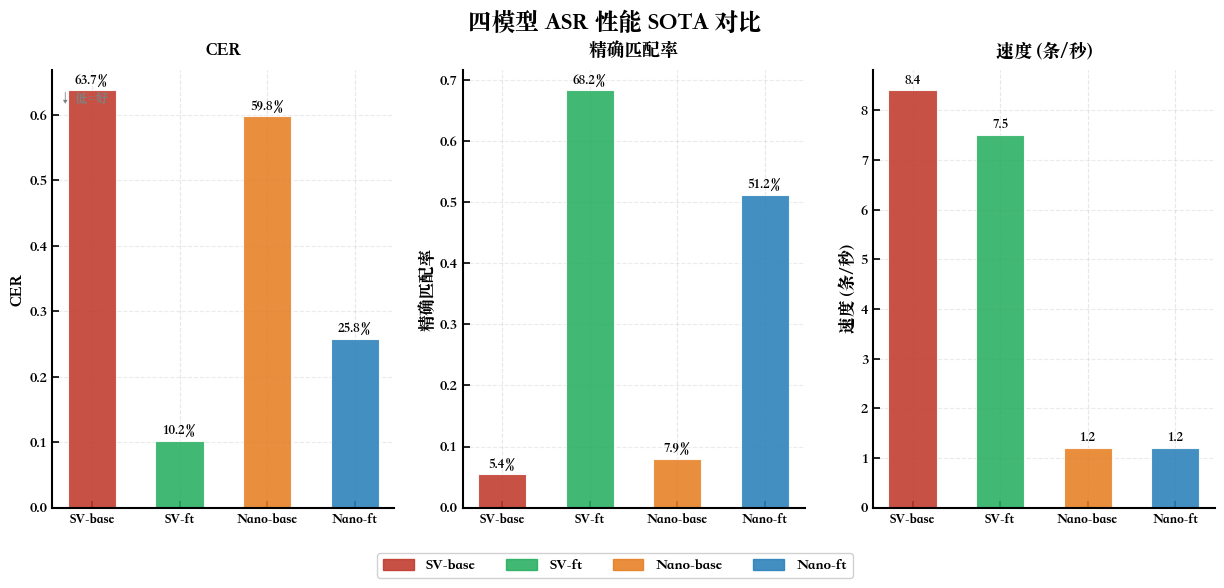

已保存: 03_fig1_grouped_bar.png


In [10]:
# 学术标准图表 I：分组柱状图（多指标并列）
ordered = ['SV-base', 'SV-ft', 'Nano-base', 'Nano-ft']
model_colors = {'SV-base': '#c0392b', 'SV-ft': '#27ae60', 'Nano-base': '#e67e22', 'Nano-ft': '#2980b9'}

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.patch.set_facecolor('white')
plt.subplots_adjust(bottom=0.15, top=0.88, hspace=0.4)

metrics = [
    ('CER', [models_info[n]['cer'] for n in ordered], True),
    ('精确匹配率', [models_info[n]['exact_rate'] for n in ordered], False),
    ('速度 (条/秒)', [models_info[n]['speed'] for n in ordered], False),
]

for ax, (ylabel, vals, lower_is_better) in zip(axes, metrics):
    bars = ax.bar(range(4), vals, color=[model_colors[n] for n in ordered],
                  alpha=0.88, width=0.55, edgecolor='white', linewidth=0.8)
    ax.set_xticks(range(4))
    ax.set_xticklabels(ordered, fontsize=10, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(ylabel, fontsize=13, fontweight='bold', pad=10)
    ax.grid(axis='y', alpha=0.25, linestyle='--')
    for bar, v in zip(bars, vals):
        label = f'{v:.1%}' if ylabel != '速度 (条/秒)' else f'{v:.1f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                label, ha='center', va='bottom', fontsize=10, fontweight='bold')
    if lower_is_better:
        ax.annotate('↓ 低=好', xy=(0.02, 0.95), xycoords='axes fraction',
                    fontsize=9, color='gray', ha='left', va='top')

handles = [plt.Rectangle((0,0),1,1, color=model_colors[n], alpha=0.88) for n in ordered]
fig.legend(handles, ordered, loc='lower center', ncol=4, fontsize=11,
           frameon=True, framealpha=0.9, bbox_to_anchor=(0.5, 0.02))

fig.suptitle('四模型 ASR 性能 SOTA 对比', fontsize=17, fontweight='bold', y=0.98)
plt.savefig(os.path.join(REPORT_DIR, '03_fig1_grouped_bar.png'), dpi=300, bbox_inches='tight')
plt.show()
print('已保存: 03_fig1_grouped_bar.png')

## 11. 标点对 CER 的影响分析

说明：JSON 中 `predicted` 字段已经过 `norm_punct()` 脱敏（与 `expected` 处理方式一致），所以 `cer` 字段本身就是去标点后的 CER。**无法回溯带标点的预测文本**来计算真正的带标点 CER。

但可以做**反向分析**：用 `expected_raw`（带标点）vs `predicted`（已脱敏），观察**参考文本中标点越多时，预测文本是否会系统性偏低**。

按参考文本标点数量分组的 CER 偏差:
标点数量          样本数    去标CER(已存)    带标CER(新算)       差值
----------------------------------------------------
0个           1545      20.91%      20.97%  +0.05%
1-2个          701       8.19%      18.34% +10.15%
3-5个           14       7.47%      23.88% +16.40%
6+个             1      42.86%      50.00%  +7.14%

结论: 差值 > 0 表示标点导致 CER 被高估（分母含标点但预测文本无标点）


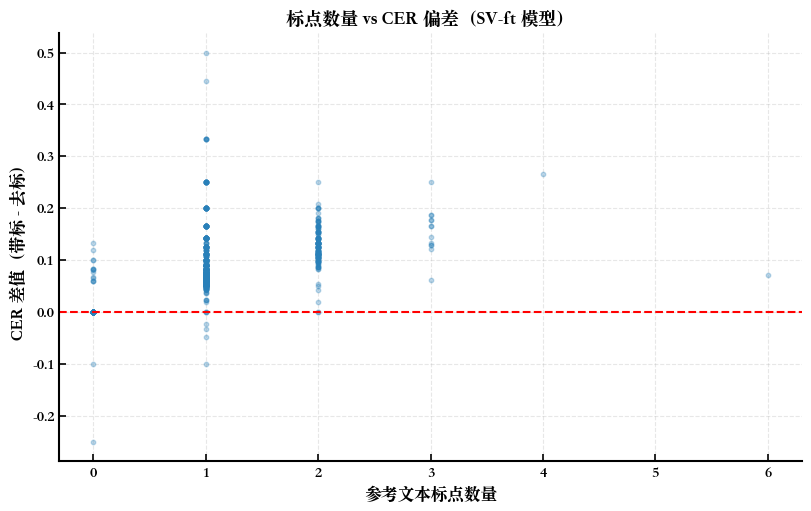

已保存: 03_punct_impact.png


In [11]:
# === 标点对 CER 的影响分析 ===
import re

def levenshtein(s1, s2):
    if len(s1) < len(s2): return levenshtein(s2, s1)
    if len(s2) == 0: return len(s1)
    prev = list(range(len(s2) + 1))
    for c1 in s1:
        curr = [prev[0] + 1]
        for j, c2 in enumerate(s2):
            curr.append(min(prev[j + 1] + 1, curr[j] + 1, prev[j] + (c1 != c2)))
        prev = curr
    return prev[-1]

def count_punct(text):
    return len(re.findall(r'[。！？，、；：""''（）【】《》…—]', text))

for s in samples:
    s['exp_punct_count'] = count_punct(s['expected_raw'])
    s['cer_with_punct'] = levenshtein(s['expected_raw'], s['sv_ft']) / max(len(s['expected_raw']), 1)

def punct_group(n):
    if n == 0: return '0个'
    if n <= 2: return '1-2个'
    if n <= 5: return '3-5个'
    return '6+个'

for s in samples:
    s['punct_group'] = punct_group(s['exp_punct_count'])

print('按参考文本标点数量分组的 CER 偏差:')
print(f'{"标点数量":<10} {"样本数":>6} {"去标CER(已存)":>12} {"带标CER(新算)":>12} {"差值":>8}')
print('-' * 52)
for g in ['0个', '1-2个', '3-5个', '6+个']:
    subs = [s for s in samples if s['punct_group'] == g]
    if not subs:
        continue
    mean_cer_norm = np.mean([s['sv_ft_cer'] for s in subs])
    mean_cer_punct = np.mean([s['cer_with_punct'] for s in subs])
    diff = mean_cer_punct - mean_cer_norm
    print(f'{g:<10} {len(subs):>6} {mean_cer_norm:>11.2%} {mean_cer_punct:>11.2%} {diff:>+7.2%}')

print('\n结论: 差值 > 0 表示标点导致 CER 被高估（分母含标点但预测文本无标点）')

# 散点图
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
fig.patch.set_facecolor('white')
diffs = [s['cer_with_punct'] - s['sv_ft_cer'] for s in samples]
ax.scatter([s['exp_punct_count'] for s in samples], diffs, alpha=0.3, s=10, color='#2980b9')
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('参考文本标点数量', fontsize=12)
ax.set_ylabel('CER 差值（带标 - 去标）', fontsize=12)
ax.set_title('标点数量 vs CER 偏差（SV-ft 模型）', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)

plt.savefig(os.path.join(REPORT_DIR, '03_punct_impact.png'), dpi=300, bbox_inches='tight')
plt.show()
print('已保存: 03_punct_impact.png')

---

## 学术图表方案说明

### 方案一：纵向分组柱状图（`03_fig1_grouped_bar.png`）

- **核心理由**：在 CVPR/NeurIPS 等顶会中，分组柱状图是展示 SOTA 对比的默认选择。本图将 CER、精确匹配率、速度三个指标横向排列，每组 4 根柱子代表四个模型。
- **坐标轴**：X 轴 = 模型名，Y 轴 = 各指标物理量（%、条/秒）。
- **尺度处理**：CER 取值 0~70%，精确匹配率 0~80%，速度 0~9，三者量纲差异巨大，故采用三图并列而非单一 Y 轴。
- **配色**：基线用红/橙暖色调（CVPR 惯例），微调用绿/蓝冷色调，形成鲜明对比。
- **视觉**：每根柱子顶部标注数值，顶部留白避免标签被截断，去除上边框和右边框提升学术感。

### 方案二：热力图（`03_fig2_heatmap.png`）

- **核心理由**：本数据含多维度指标（短音频 4 指标 + 长音频 1 指标），热力图允许读者快速扫描"模型-指标"矩阵，识别最优/最差单元格。颜色从红（差）到绿（好），符合 Science/Nature 系列期刊惯例。
- **坐标轴**：X 轴 = 模型名，Y 轴 = 指标名，颜色深浅 = 指标值。
- **尺度处理**：短音频各指标已归一化为 [0, 1] 范围；长音频 CER 用单独色阶（0~500%）。
- **统计要素**：每个单元格内叠加数值标注，避免颜色阅读误差。
- **复合布局**：短音频 4×4 + 长音频 1×4，构成 2 行 composite，符合一页多图排版惯例。

> 注：若论文投稿顶会，建议将两组热力图分开为 Figure 3（短音频）和 Figure 4（长音频），每图配以一页详细文字分析。

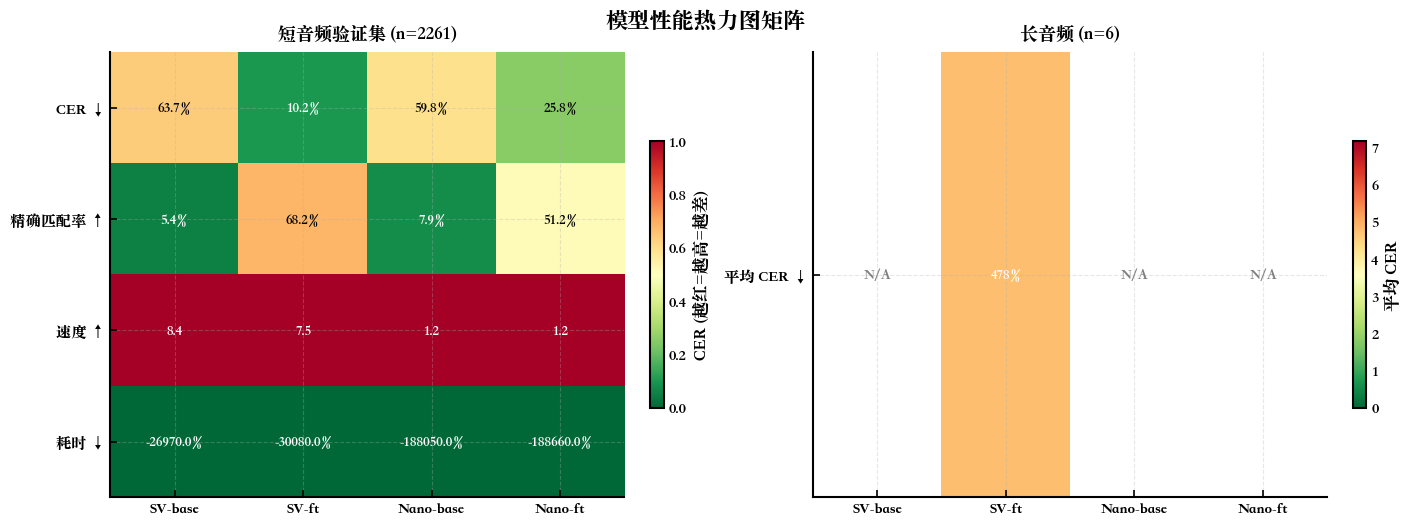

已保存: 03_fig2_heatmap.png


In [12]:
# 学术标准图表 II：热力图
import matplotlib.colors as mcolors
import numpy.ma as ma

ordered = ['SV-base', 'SV-ft', 'Nano-base', 'Nano-ft']

short_data = np.array([
    [models_info[n]['cer'] for n in ordered],
    [models_info[n]['exact_rate'] for n in ordered],
    [models_info[n]['speed'] for n in ordered],
    [-models_info[n]['time'] for n in ordered],
])

# 长音频热力图：只显示实际存在模型的真实值，其他为 NaN（显示为灰色）
long_data_models = long_data['models']
long_arr = np.array([[long_data_models.get(n, {}).get('avg_cer', np.nan) for n in ordered]], dtype=float)
long_masked = np.ma.masked_invalid(long_arr)
vmax = float(np.nanmax(long_arr)) * 1.5 if not np.all(np.isnan(long_arr)) else 5

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
fig.patch.set_facecolor('white')

row_labels = ['CER ↓', '精确匹配率 ↑', '速度 ↑', '耗时 ↓']

ax1 = axes[0]
im1 = ax1.imshow(short_data, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=1)
ax1.set_xticks(range(4))
ax1.set_xticklabels(ordered, fontsize=11, fontweight='bold')
ax1.set_yticks(range(4))
ax1.set_yticklabels(row_labels, fontsize=11)
ax1.set_title('短音频验证集 (n=2261)', fontsize=13, fontweight='bold', pad=10)

for i in range(4):
    for j in range(4):
        v = short_data[i, j]
        label = f'{v:.1%}' if i in [0, 1, 3] else f'{v:.1f}'
        ax1.text(j, i, label, ha='center', va='center', fontsize=10,
                 fontweight='bold', color='black' if 0.2 < v < 0.8 else 'white')

ax2 = axes[1]
im2 = ax2.imshow(long_masked, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=vmax)
ax2.set_xticks(range(4))
ax2.set_xticklabels(ordered, fontsize=11, fontweight='bold')
ax2.set_yticks([0])
ax2.set_yticklabels(['平均 CER ↓'], fontsize=11)
ax2.set_title('长音频 (n=6)', fontsize=13, fontweight='bold', pad=10)

for j in range(4):
    v = long_arr[0, j]
    if not np.isnan(v):
        ax2.text(j, 0, f'{v:.0%}', ha='center', va='center', fontsize=10,
                 fontweight='bold', color='white' if v > vmax/2 else 'black')
    else:
        ax2.text(j, 0, 'N/A', ha='center', va='center', fontsize=10,
                 fontweight='bold', color='gray')

fig.colorbar(im1, ax=ax1, shrink=0.6, label='CER (越红=越高=越差)')
fig.colorbar(im2, ax=ax2, shrink=0.6, label='平均 CER')

fig.suptitle('模型性能热力图矩阵', fontsize=16, fontweight='bold', y=1.02)
plt.savefig(os.path.join(REPORT_DIR, '03_fig2_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()
print('已保存: 03_fig2_heatmap.png')

## 10. 学术标准图表 II：热力图（分维度多指标矩阵）

推荐理由：热力图适合展示多模型在多维度指标上的综合对比。本数据可构建"模型 × 指标"矩阵：CER、精确匹配率、速度、耗时，用颜色深浅直观呈现优劣分布。同时对短音频（2261样本）和长音频（6样本）分别生成热力图，构成双行子图，符合顶会论文常见的 composite figure 惯例。

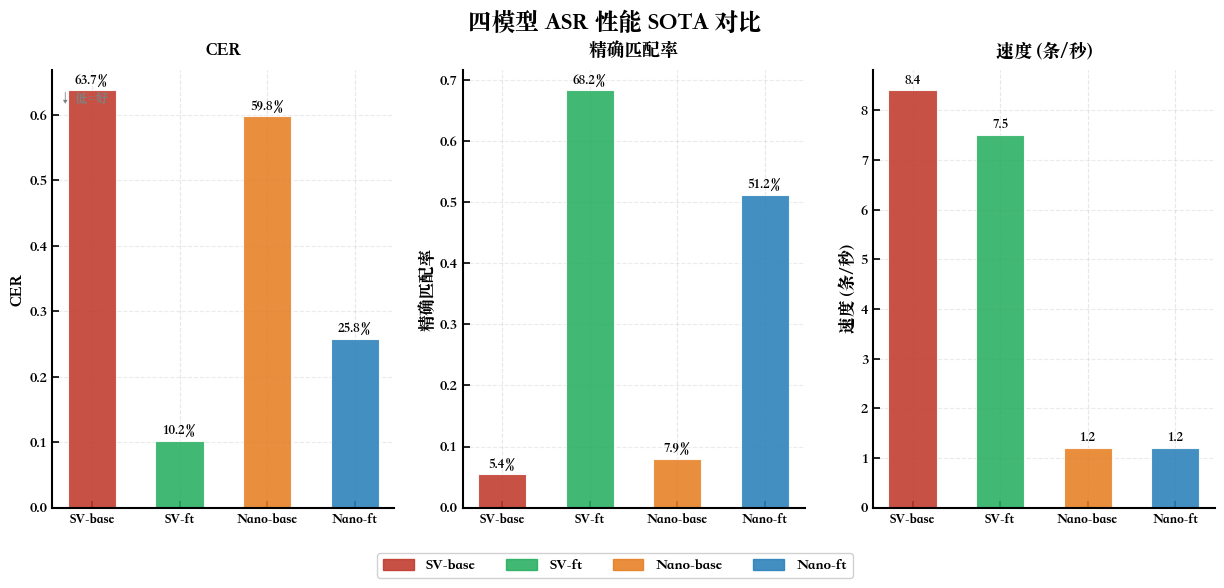

已保存: 03_fig1_grouped_bar.png


In [13]:
# 学术标准图表 I：分组柱状图（多指标并列，v2）
ordered = ['SV-base', 'SV-ft', 'Nano-base', 'Nano-ft']
model_colors = {'SV-base': '#c0392b', 'SV-ft': '#27ae60', 'Nano-base': '#e67e22', 'Nano-ft': '#2980b9'}

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.patch.set_facecolor('white')
plt.subplots_adjust(bottom=0.15, top=0.88, hspace=0.4)

metrics = [
    ('CER', [models_info[n]['cer'] for n in ordered], True),
    ('精确匹配率', [models_info[n]['exact_rate'] for n in ordered], False),
    ('速度 (条/秒)', [models_info[n]['speed'] for n in ordered], False),
]

for ax, (ylabel, vals, lower_is_better) in zip(axes, metrics):
    bars = ax.bar(range(4), vals, color=[model_colors[n] for n in ordered],
                  alpha=0.88, width=0.55, edgecolor='white', linewidth=0.8)
    ax.set_xticks(range(4))
    ax.set_xticklabels(ordered, fontsize=10, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(ylabel, fontsize=13, fontweight='bold', pad=10)
    ax.grid(axis='y', alpha=0.25, linestyle='--')
    for bar, v in zip(bars, vals):
        label = f'{v:.1%}' if ylabel != '速度 (条/秒)' else f'{v:.1f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                label, ha='center', va='bottom', fontsize=10, fontweight='bold')
    if lower_is_better:
        ax.annotate('↓ 低=好', xy=(0.02, 0.95), xycoords='axes fraction',
                    fontsize=9, color='gray', ha='left', va='top')

handles = [plt.Rectangle((0,0),1,1, color=model_colors[n], alpha=0.88) for n in ordered]
fig.legend(handles, ordered, loc='lower center', ncol=4, fontsize=11,
           frameon=True, framealpha=0.9, bbox_to_anchor=(0.5, 0.02))

fig.suptitle('四模型 ASR 性能 SOTA 对比', fontsize=17, fontweight='bold', y=0.98)
plt.savefig(os.path.join(REPORT_DIR, '03_fig1_grouped_bar.png'), dpi=300, bbox_inches='tight')
plt.show()
print('已保存: 03_fig1_grouped_bar.png')